# Punto 3 (0.9) — Transformaciones de intensidad: gamma y logarítmica

Nota: usa como entrada la imagen original en escala de grises. Asegúrate que las imágenes resultantes están en uint8 (rango 0-255).

In [1]:
# numpy: manejo de la imagen como matriz (arreglo N-dimensional) y toda la
#        indexación (recortes, reflexiones, reordenar canales).
# matplotlib.pyplot: mostrar y guardar (savefig) las imágenes resultantes.
# PIL.Image: leer archivos de imagen (.png/.tif) y convertir entre modos
#            de color (RGB, L = escala de grises).
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# sys.path.append("..") permite importar utils.py, que está un nivel arriba
# (en la raíz del proyecto), desde dentro de la carpeta notebooks/.
import sys
sys.path.append("..")
from utils import to_uint8, gamma_transform, log_transform, piecewise_linear, gray_level_slicing


## Imagen Original en Escala de Grises



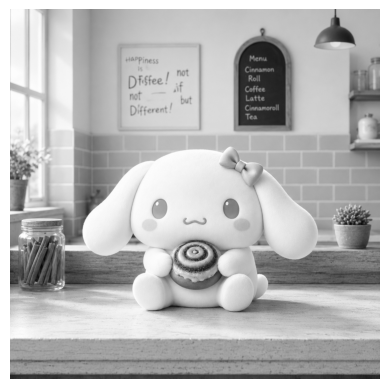

In [2]:
img = np.array(Image.open("../images/cinnamorroll_1024.png").convert("RGB"))
# convert("L"): modo "L" de PIL = escala de grises de 8 bits (0-255,
# un solo byte por pixel), calculado como una combinación ponderada
# de los canales R, G y B.
gray = np.array(Image.fromarray(img).convert("L"))

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto3_gris.png", bbox_inches="tight", pad_inches=0)


## Transformación Gamma (γ=0.3)



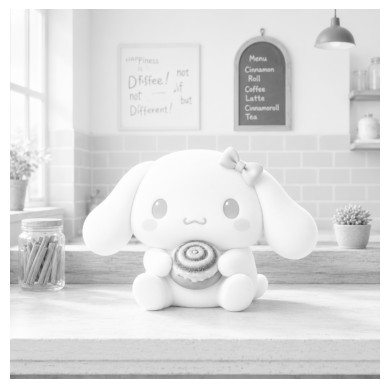

In [3]:
# gamma_transform (utils.py) aplica s = c * r^gamma sobre cada pixel,
# con r normalizado a [0,1]. Usa numpy para la potencia elemento a
# elemento y to_uint8 (también en utils.py) para reescalar el
# resultado de vuelta a enteros de 0 a 255.
# gamma=0.3 (<1): aclara la imagen, expande los tonos oscuros.
gamma_03 = gamma_transform(gray, 0.3)

plt.imshow(gamma_03, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto3_gamma_0.3.png", bbox_inches="tight", pad_inches=0)


## Transformación Gamma (γ=2.3)



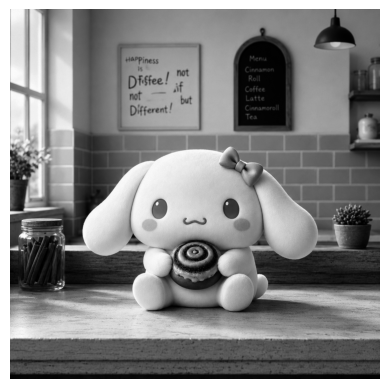

In [4]:
# gamma=2.3 (>1): oscurece la imagen, expande los tonos claros
# comprimiendo los oscuros.
gamma_23 = gamma_transform(gray, 2.3)

plt.imshow(gamma_23, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto3_gamma_2.3.png", bbox_inches="tight", pad_inches=0)


## Transformación Logarítmica



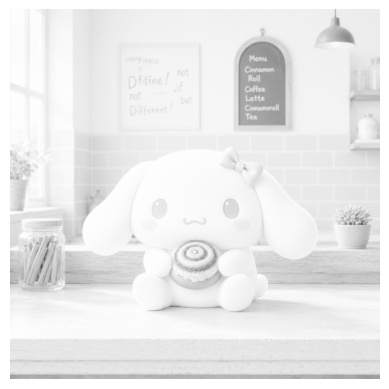

In [5]:
# log_transform (utils.py) aplica s = c * log(1 + r) con numpy
# (np.log). A diferencia de gamma, no tiene un parámetro que cambie
# su dirección: siempre aclara, y lo hace con más fuerza en los
# tonos oscuros que en los claros.
log_img = log_transform(gray)

plt.imshow(log_img, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto3_log.png", bbox_inches="tight", pad_inches=0)
